# Eksperimen SML — Klasifikasi Spesies Palmer Penguins
**Nama:** Dafina Meira Rizkia

Notebook ini merupakan tahap eksplorasi (Kriteria 1) sebelum otomatisasi. Alur mengikuti
Template Eksperimen MSML: *data loading* → *exploratory data analysis* → *data preprocessing*,
lalu menyimpan dataset yang sudah siap dilatih.

Dataset: **Palmer Penguins** — 344 baris pengukuran morfologi tiga spesies penguin
(*Adelie*, *Chinstrap*, *Gentoo*) di Kepulauan Palmer, Antarktika. Tujuan: memprediksi
`species` dari ciri fisik dan lokasi pengamatan.

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 11
print("Library siap.")

Library siap.


## 2. Data Loading

Memuat berkas mentah `penguins_raw.csv`. Berkas ini disimpan berdampingan dengan notebook
di dalam repository eksperimen.

In [2]:
raw = pd.read_csv("../penguins_raw.csv")
print("Dimensi data mentah:", raw.shape)
raw.head()

Dimensi data mentah: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


## 3. Exploratory Data Analysis (EDA)

Beberapa hal yang ingin dipahami sebelum preprocessing:
1. Distribusi kelas target `species` (seimbang atau tidak).
2. Jumlah nilai kosong (*missing values*) tiap kolom.
3. Sebaran dan hubungan antar fitur numerik.
4. Komposisi fitur kategorikal (`island`, `sex`).

### 3.1 Ringkasan statistik fitur numerik

In [4]:
raw.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


### 3.2 Distribusi kelas target

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


C:\Users\Admin Kalachakra\AppData\Local\Temp\ipykernel_21540\891444240.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=raw, x="species", order=dist.index, palette="crest")


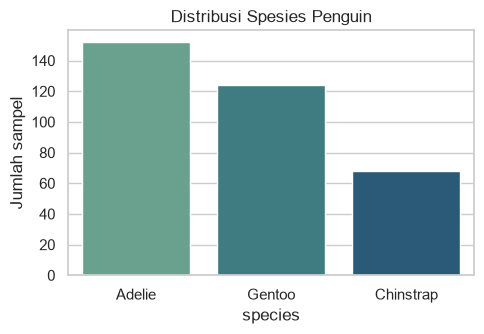

In [5]:
dist = raw["species"].value_counts()
print(dist)
plt.figure(figsize=(5, 3.5))
sns.countplot(data=raw, x="species", order=dist.index, palette="crest")
plt.title("Distribusi Spesies Penguin")
plt.ylabel("Jumlah sampel")
plt.tight_layout()
plt.show()

### 3.3 Pemeriksaan nilai kosong

In [6]:
missing = raw.isna().sum()
print(missing)
print("\nTotal baris dengan minimal satu nilai kosong:",
      raw.isna().any(axis=1).sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Total baris dengan minimal satu nilai kosong: 11


### 3.4 Sebaran fitur numerik terhadap spesies

C:\Users\Admin Kalachakra\AppData\Local\Temp\ipykernel_21540\164130071.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw, x="species", y=col, ax=ax, palette="crest")
C:\Users\Admin Kalachakra\AppData\Local\Temp\ipykernel_21540\164130071.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw, x="species", y=col, ax=ax, palette="crest")


C:\Users\Admin Kalachakra\AppData\Local\Temp\ipykernel_21540\164130071.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw, x="species", y=col, ax=ax, palette="crest")
C:\Users\Admin Kalachakra\AppData\Local\Temp\ipykernel_21540\164130071.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw, x="species", y=col, ax=ax, palette="crest")


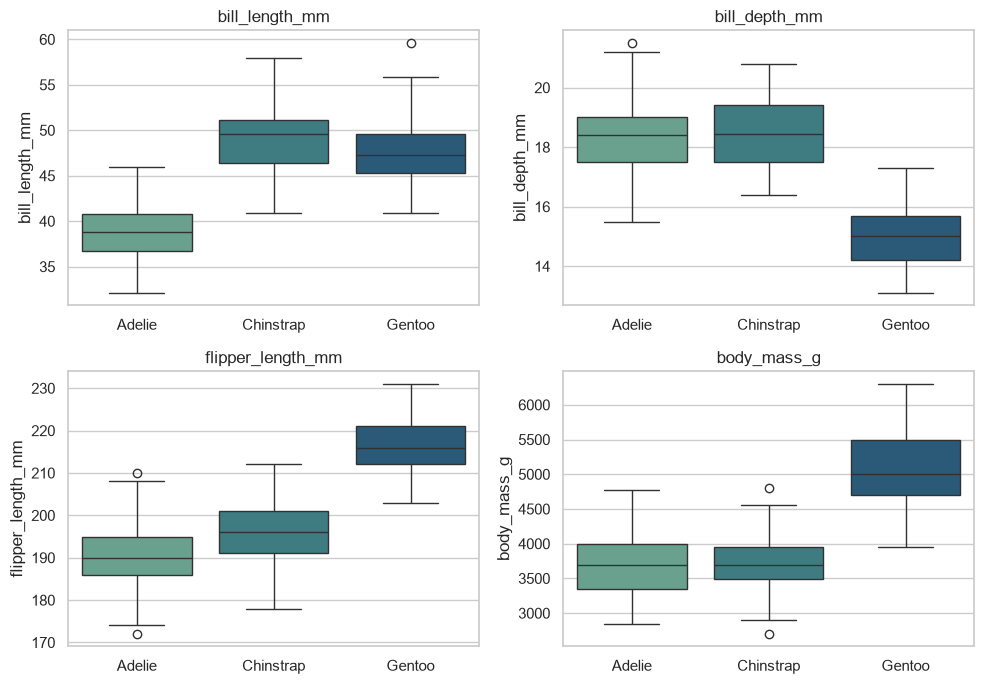

In [7]:
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=raw, x="species", y=col, ax=ax, palette="crest")
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

### 3.5 Korelasi antar fitur numerik

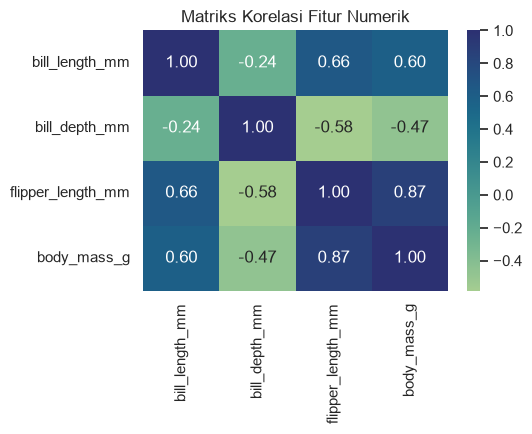

In [8]:
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(raw[num_cols].corr(), annot=True, cmap="crest", fmt=".2f")
plt.title("Matriks Korelasi Fitur Numerik")
plt.tight_layout()
plt.show()

### 3.6 Komposisi fitur kategorikal

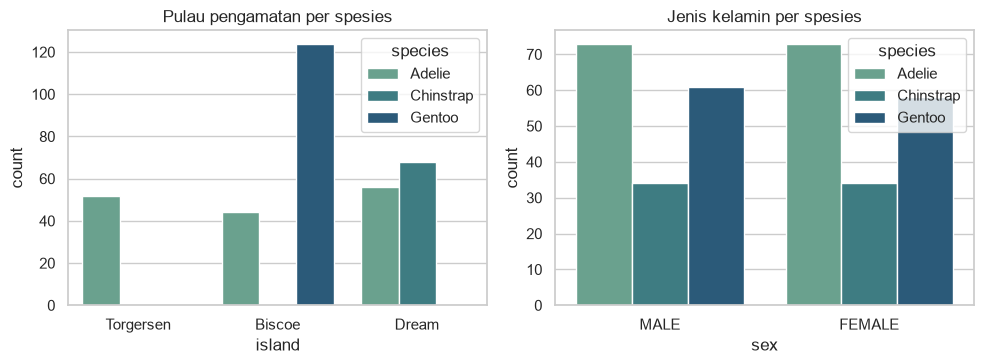

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
sns.countplot(data=raw, x="island", hue="species", ax=axes[0], palette="crest")
axes[0].set_title("Pulau pengamatan per spesies")
sns.countplot(data=raw, x="sex", hue="species", ax=axes[1], palette="crest")
axes[1].set_title("Jenis kelamin per spesies")
plt.tight_layout()
plt.show()

**Temuan EDA:**
- Kelas sedikit tidak seimbang (*Adelie* terbanyak, *Chinstrap* paling sedikit) — masih wajar.
- Terdapat nilai kosong: 2 baris pada seluruh kolom pengukuran dan 11 baris pada `sex`.
- `flipper_length_mm` dan `body_mass_g` berkorelasi kuat; ukuran tubuh membedakan *Gentoo* dengan jelas.
- `island` cukup diskriminatif (mis. *Gentoo* hanya di Biscoe).

## 4. Data Preprocessing

Langkah-langkah agar data siap dilatih:
1. **Menangani nilai kosong** — membuang baris yang mengandung *missing value* (jumlahnya kecil).
2. **Encoding kategorikal** — `island` di-*one-hot encode*, `sex` diubah menjadi biner.
3. **Encoding target** — `species` di-*label encode* menjadi 0/1/2.
4. **Standardisasi** — fitur numerik diskalakan dengan `StandardScaler` (mean 0, varians 1).

### 4.1 Menangani nilai kosong

In [10]:
df = raw.dropna().reset_index(drop=True)
print("Setelah membuang baris kosong:", df.shape)
print("Sisa nilai kosong:", int(df.isna().sum().sum()))

Setelah membuang baris kosong: (333, 7)
Sisa nilai kosong: 0


### 4.2 Encoding fitur kategorikal & target

In [11]:
# Target: species -> 0/1/2
target_encoder = LabelEncoder()
df["species"] = target_encoder.fit_transform(df["species"])
print("Peta label target:",
      dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

# sex -> biner (male = 1, female = 0)
df["sex"] = (df["sex"].str.upper() == "MALE").astype(int)

# island -> one-hot
df = pd.get_dummies(df, columns=["island"], prefix="island")
# ubah kolom hasil one-hot dari boolean menjadi integer 0/1
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)
df.head()

Peta label target: {'Adelie': np.int64(0), 'Chinstrap': np.int64(1), 'Gentoo': np.int64(2)}


,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_Biscoe,island_Dream,island_Torgersen
0,0,39.1,18.7,181.0,3750.0,1,0,0,1
1,0,39.5,17.4,186.0,3800.0,0,0,0,1
2,0,40.3,18.0,195.0,3250.0,0,0,0,1
3,0,36.7,19.3,193.0,3450.0,0,0,0,1
4,0,39.3,20.6,190.0,3650.0,1,0,0,1


### 4.3 Standardisasi fitur numerik

In [12]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df[num_cols].describe().loc[["mean", "std"]].round(3)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
mean,0.000,0.000,0.000,-0.000
std,1.002,1.002,1.002,1.002


### 4.4 Data akhir yang siap dilatih

In [13]:
print("Dimensi akhir:", df.shape)
print("Kolom:", list(df.columns))
df.head()

Dimensi akhir: (333, 9)
Kolom: ['species', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'island_Biscoe', 'island_Dream', 'island_Torgersen']


,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_Biscoe,island_Dream,island_Torgersen
0,0,-0.896042,0.780732,-1.426752,-0.568475,1,0,0,1
1,0,-0.822788,0.119584,-1.069474,-0.506286,0,0,0,1
2,0,-0.676280,0.424729,-0.426373,-1.190361,0,0,0,1
3,0,-1.335566,1.085877,-0.569284,-0.941606,0,0,0,1
4,0,-0.859415,1.747026,-0.783651,-0.692852,1,0,0,1


## 5. Menyimpan Dataset Siap Latih

Menyimpan hasil preprocessing ke `penguins_preprocessing.csv`. Berkas inilah yang akan
dipakai pada tahap pembangunan model (Kriteria 2) dan workflow CI (Kriteria 3).

In [14]:
out_path = "penguins_preprocessing.csv"
df.to_csv(out_path, index=False)
print("Tersimpan:", out_path, "->", df.shape)

Tersimpan: penguins_preprocessing.csv -> (333, 9)
